In [1]:
from pathlib import Path
import tarfile
import gzip
import shutil
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
# Set working directory to your GSE190487 folder
base_dir = Path.cwd()

# Input tar file
tar_path = base_dir / "GSE190487_RAW.tar"

# Folder where tar contents will be extracted
extract_dir = base_dir / "raw_extracted"

# Output h5ad path
out_path = base_dir / "GSE190487_NAFLD_liver_scRNA_raw.h5ad"

print("Base directory:", base_dir)
print("Tar exists:", tar_path.exists())

Base directory: c:\Users\ankit\Documents\scFM\train_data\GSE190487
Tar exists: True


In [3]:
extract_dir.mkdir(exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_dir)

print("Extraction complete.")
print("Extracted files:")
for p in sorted(extract_dir.rglob("*")):
    if p.is_file():
        print(p.relative_to(extract_dir))

Extraction complete.
Extracted files:
GSM5724573_nafld1_barcodes.tsv.gz
GSM5724573_nafld1_features.tsv.gz
GSM5724573_nafld1_matrix.mtx.gz


In [4]:
def find_first_file(folder, patterns):
    for pattern in patterns:
        matches = list(folder.rglob(pattern))
        if matches:
            return matches[0]
    return None

matrix_file = find_first_file(extract_dir, ["*matrix.mtx", "*matrix.mtx.gz", "*.mtx", "*.mtx.gz"])
barcode_file = find_first_file(extract_dir, ["*barcodes.tsv", "*barcodes.tsv.gz"])
feature_file = find_first_file(extract_dir, ["*features.tsv", "*features.tsv.gz", "*genes.tsv", "*genes.tsv.gz"])

print("Matrix file :", matrix_file)
print("Barcode file:", barcode_file)
print("Feature file:", feature_file)

Matrix file : c:\Users\ankit\Documents\scFM\train_data\GSE190487\raw_extracted\GSM5724573_nafld1_matrix.mtx.gz
Barcode file: c:\Users\ankit\Documents\scFM\train_data\GSE190487\raw_extracted\GSM5724573_nafld1_barcodes.tsv.gz
Feature file: c:\Users\ankit\Documents\scFM\train_data\GSE190487\raw_extracted\GSM5724573_nafld1_features.tsv.gz


In [5]:
from scipy.io import mmread
from scipy import sparse

In [6]:
def read_table_auto(path):
    if path.suffix == ".gz":
        return pd.read_csv(path, sep="\t", header=None, compression="gzip")
    return pd.read_csv(path, sep="\t", header=None)

def read_mtx_auto(path):
    if path.suffix == ".gz":
        with gzip.open(path, "rb") as f:
            return mmread(f).tocsr()
    return mmread(path).tocsr()

# Read files
X = read_mtx_auto(matrix_file)
barcodes = read_table_auto(barcode_file)
features = read_table_auto(feature_file)

print("Raw matrix shape from MTX:", X.shape)
print("Barcodes shape:", barcodes.shape)
print("Features shape:", features.shape)

Raw matrix shape from MTX: (33538, 6794880)
Barcodes shape: (6794880, 1)
Features shape: (33538, 3)


In [7]:
n_barcodes = barcodes.shape[0]
n_features = features.shape[0]

print("Expected cells :", n_barcodes)
print("Expected genes :", n_features)
print("Current X shape:", X.shape)

# If X is genes x cells, transpose it
if X.shape == (n_features, n_barcodes):
    X = X.T.tocsr()
    print("Transposed matrix to cells x genes.")
elif X.shape == (n_barcodes, n_features):
    print("Matrix already in cells x genes format.")
else:
    raise ValueError(
        f"Matrix shape {X.shape} does not match "
        f"(genes, cells)=({n_features}, {n_barcodes}) or "
        f"(cells, genes)=({n_barcodes}, {n_features})."
    )

print("Final X shape:", X.shape)

Expected cells : 6794880
Expected genes : 33538
Current X shape: (33538, 6794880)
Transposed matrix to cells x genes.
Final X shape: (6794880, 33538)


In [8]:
# Cell metadata
obs = pd.DataFrame(index=barcodes.iloc[:, 0].astype(str).values)
obs.index.name = "barcode"

# Gene metadata
var = pd.DataFrame(index=features.iloc[:, 0].astype(str).values)
var.index.name = "gene_id"

if features.shape[1] >= 2:
    var["gene_symbol"] = features.iloc[:, 1].astype(str).values
else:
    var["gene_symbol"] = var.index.astype(str)

if features.shape[1] >= 3:
    var["feature_type"] = features.iloc[:, 2].astype(str).values
else:
    var["feature_type"] = "Gene Expression"

print(obs.head())
print(var.head())

Empty DataFrame
Columns: []
Index: [AAACCCAAGAAACACT-1, AAACCCAAGAAACCAT-1, AAACCCAAGAAACCCA-1, AAACCCAAGAAACCCG-1, AAACCCAAGAAACCTG-1]
                 gene_symbol     feature_type
gene_id                                      
ENSG00000243485  MIR1302-2HG  Gene Expression
ENSG00000237613      FAM138A  Gene Expression
ENSG00000186092        OR4F5  Gene Expression
ENSG00000238009   AL627309.1  Gene Expression
ENSG00000239945   AL627309.3  Gene Expression


In [9]:
adata = sc.AnnData(X=X, obs=obs, var=var)

# Make gene names unique using gene symbols if available
adata.var_names = adata.var["gene_symbol"].astype(str).values
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 6794880 × 33538
    var: 'gene_symbol', 'feature_type'


In [10]:
adata.obs["gsm_id"] = "GSM5724573"
adata.obs["study"] = "GSE190487"
adata.obs["disease"] = "NAFLD"
adata.obs["tissue"] = "liver"
adata.obs["assay"] = "scRNA-seq"

In [11]:
adata.layers["counts"] = adata.X.copy()

In [12]:
print(adata)
print("\nObs columns:")
print(adata.obs.columns.tolist())

print("\nVar columns:")
print(adata.var.columns.tolist())

print("\nNumber of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

# Total counts per cell
adata.obs["n_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()

# Genes detected per cell
adata.obs["n_genes"] = np.asarray((adata.X > 0).sum(axis=1)).ravel()

print("\nCell-level summary:")
print(adata.obs[["n_counts", "n_genes"]].describe())

AnnData object with n_obs × n_vars = 6794880 × 33538
    obs: 'gsm_id', 'study', 'disease', 'tissue', 'assay'
    var: 'gene_symbol', 'feature_type'
    layers: 'counts'

Obs columns:
['gsm_id', 'study', 'disease', 'tissue', 'assay']

Var columns:
['gene_symbol', 'feature_type']

Number of cells: 6794880
Number of genes: 33538

Cell-level summary:
           n_counts       n_genes
count  6.794880e+06  6.794880e+06
mean   6.538736e+00  2.712510e+00
std    2.305269e+02  5.846155e+01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    0.000000e+00  0.000000e+00
75%    0.000000e+00  0.000000e+00
max    5.722400e+04  5.616000e+03


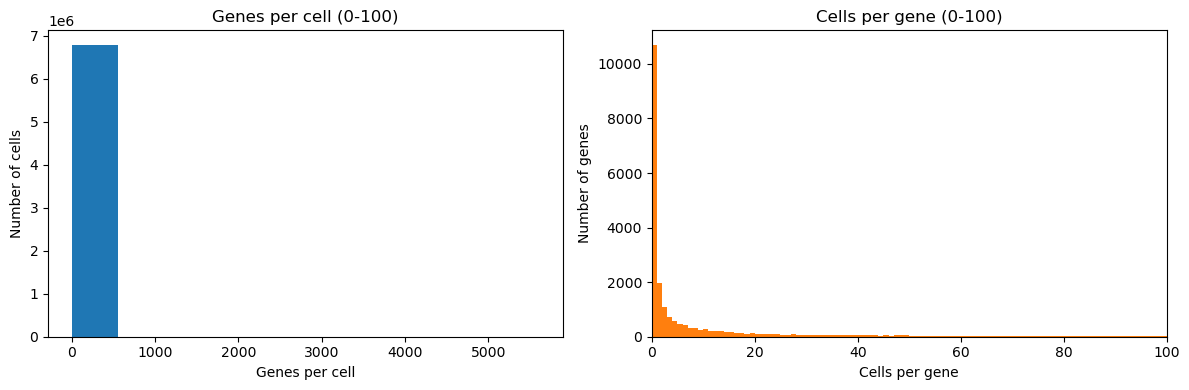

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell)#, bins=np.arange(0, 102), color="C0")#,=(0, 100))
#axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [15]:
# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell == min_genes_per_cell)
print(f"Number of cells with at least {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 0
Number of cells with at least 0 genes: 5984600


In [16]:
# Remove cells with zero genes detected
adata = adata[genes_per_cell > 0, :].copy()
print(adata)

AnnData object with n_obs × n_vars = 810280 × 33538
    obs: 'gsm_id', 'study', 'disease', 'tissue', 'assay', 'n_counts', 'n_genes'
    var: 'gene_symbol', 'feature_type'
    layers: 'counts'


In [17]:
adata.write_h5ad(out_path)
print("Saved to:", out_path)

Saved to: c:\Users\ankit\Documents\scFM\train_data\GSE190487\GSE190487_NAFLD_liver_scRNA_raw.h5ad


In [3]:
# Read back the saved file to verify
adata = sc.read_h5ad(out_path)
print(adata)

AnnData object with n_obs × n_vars = 810280 × 33538
    obs: 'gsm_id', 'study', 'disease', 'tissue', 'assay', 'n_counts', 'n_genes'
    var: 'gene_symbol', 'feature_type'
    layers: 'counts'
